# Performance comparison between Swiftlet and Lark parsing library

Import required library

In [1]:
import random as rnd

import pandas as pd
import seaborn as sns
import timeit
import cProfile


import swiftlet
import lark

Text expression generator

In [2]:
def gen_text_expr(n):
    expr = "{}".format(rnd.randint(1, n))
    opt = ["+", "-", "*", "/"]

    for _ in range(n):
        expr += " {} {}".format(rnd.choice(opt), str(rnd.randint(1, n)))
    return expr.strip()

texts = [gen_text_expr(10 * i) for i in range(1, 500)]

## Swiftlet Parser function

In [3]:
def parser_swiftlet(text: str):
    _grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import (WS, INT)
    %ignore WS
    """
    parser = swiftlet.Swiftlet(grammar=_grammar, algorithm="clr")
    ast = parser.parse(text)
    return ast

In [4]:
parser_swiftlet("1 + 2 - 4 * 5")

Tree(start, [Tree(sub, [Tree(add, [Tree(expr, [Tree(factors, [Token(Type: INT, Word: "1", Start: 0, End: 1, Line: 0)])]), Token(Type: +, Word: "+", Start: 2, End: 3, Line: 0), Tree(factors, [Token(Type: INT, Word: "2", Start: 4, End: 5, Line: 0)])]), Token(Type: -, Word: "-", Start: 6, End: 7, Line: 0), Tree(mul, [Tree(factors, [Token(Type: INT, Word: "4", Start: 8, End: 9, Line: 0)]), Token(Type: *, Word: "*", Start: 10, End: 11, Line: 0), Token(Type: INT, Word: "5", Start: 12, End: 13, Line: 0)])])])

## Lark Parser function

In [5]:
def parser_lark(text: str):
    _grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import common.WS
    %import common.INT
    %ignore WS
    """
    _lark_parser = lark.Lark(_grammar, parser="lalr", keep_all_tokens=True)
    lark_ast = _lark_parser.parse(text=text)
    return lark_ast

In [6]:
parser_lark("1 + 2 - 4 * 5")

Tree(Token('RULE', 'start'), [Tree('sub', [Tree('add', [Tree(Token('RULE', 'expr'), [Tree(Token('RULE', 'factors'), [Token('INT', '1')])]), Token('PLUS', '+'), Tree(Token('RULE', 'factors'), [Token('INT', '2')])]), Token('MINUS', '-'), Tree('mul', [Tree(Token('RULE', 'factors'), [Token('INT', '4')]), Token('STAR', '*'), Token('INT', '5')])])])

In [7]:
number = 1000

In [8]:
array = []
for txt in texts[::100]:
    swiftlet_time = 1000 * timeit.timeit(lambda: parser_swiftlet(txt), number=number) / number
    lark_time = 1000 * timeit.timeit(lambda: parser_lark(txt), number=number) / number
    array.append([len(txt), swiftlet_time, lark_time])

   Text Length  swiftlet       lark     Ratio
0           41  0.835528   3.728515  4.462466
1         5967  2.234470   9.763207  4.369361
2        12987  3.679987  14.487536  3.936845
3        19959  4.899341  19.334211  3.946288
4        26986  6.506974  24.725532  3.799851


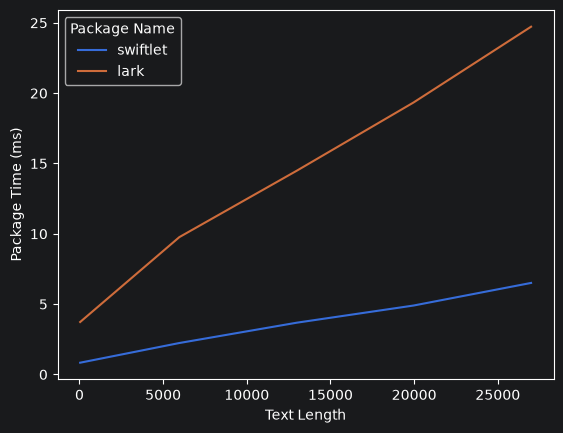

In [9]:
def grid_graph(array: list):
    df = pd.DataFrame(array, columns=['Text Length', 'swiftlet', 'lark'])
    df["Ratio"] = df["lark"] / df["swiftlet"]
    print(df)
    _df = df.melt(
        id_vars=['Text Length'],
        value_vars=['swiftlet', 'lark'],
        var_name='Package Name',
        value_name='Package Time (ms)',
    )

    sns.lineplot(_df, x="Text Length", y="Package Time (ms)", hue="Package Name")
grid_graph(array)

In [10]:
# -------------- Swiftlet ------------------ #
grammar_swiftlet = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import (WS, INT)
    %ignore WS
    """
swiftlet_parser = swiftlet.Swiftlet(grammar=grammar_swiftlet, algorithm="clr")

# -------------- Lark ------------------ #
grammar = """
    start: expr
    expr: expr "+" factors -> add
        | expr "-" factors -> sub
        | factors

    factors: factors "*" INT -> mul
        | factors "/" INT -> div
        | INT

    %import common.WS
    %import common.INT
    %ignore WS
    """
lark_parser = lark.Lark(grammar, parser="lalr", keep_all_tokens=True)


In [11]:
%%timeit
swiftlet_parser.parse(texts[-1])

6.87 ms ± 79.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
%%timeit
lark_parser.parse(texts[-1])

25.9 ms ± 237 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
arr_parsed = []
for txt in texts[::100]:
    swiftlet_time = 1000 * timeit.timeit(lambda: swiftlet_parser.parse(txt), number=number) / number
    lark_time = 1000 * timeit.timeit(lambda: lark_parser.parse(txt), number=number) / number
    arr_parsed.append([len(txt), swiftlet_time, lark_time])

   Text Length  swiftlet       lark     Ratio
0           41  0.014886   0.055483  3.727191
1         5967  1.405356   5.199093  3.699486
2        12987  2.787987  10.713740  3.842822
3        19959  4.166562  15.443106  3.706438
4        26986  5.511656  21.155006  3.838230


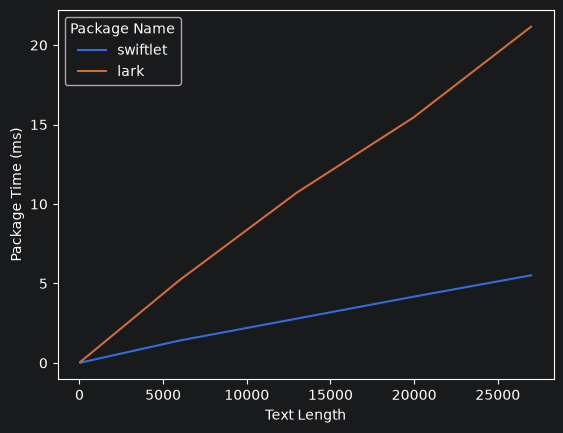

In [14]:
grid_graph(arr_parsed)

In [15]:
cProfile.run('parser_swiftlet(texts[98])')

         5 function calls in 0.003 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.002    0.002    0.003    0.003 2891851176.py:1(parser_swiftlet)
        1    0.000    0.000    0.003    0.003 <string>:1(<module>)
        1    0.000    0.000    0.003    0.003 {built-in method builtins.exec}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        1    0.001    0.001    0.001    0.001 {method 'parse' of 'swiftlet._core.Swiftlet' objects}




In [16]:
cProfile.run('parser_lark(texts[98])')

         106518 function calls (105064 primitive calls) in 0.035 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.035    0.035 595936109.py:1(parser_lark)
        2    0.000    0.000    0.000    0.000 <frozen _collections_abc>:576(_from_iterable)
        2    0.000    0.000    0.000    0.000 <frozen _collections_abc>:599(__or__)
       10    0.000    0.000    0.000    0.000 <frozen _collections_abc>:602(<genexpr>)
        8    0.000    0.000    0.000    0.000 <frozen abc>:117(__instancecheck__)
        1    0.000    0.000    0.001    0.001 <frozen importlib._bootstrap_external>:1127(get_data)
        1    0.000    0.000    0.000    0.000 <frozen importlib.util>:74(find_spec)
        1    0.000    0.000    0.000    0.000 <frozen posixpath>:150(dirname)
        4    0.000    0.000    0.000    0.000 <frozen posixpath>:41(_get_sep)
        3    0.000    0.000    0.000    0.000 <frozen posixpath>:

In [17]:
len(texts)

499

In [18]:
ast_lark = parser_lark("4 + 3 * 6 - 8 / 2")
print(ast_lark.pretty())

start
  sub
    add
      expr
        factors	4
      +
      mul
        factors	3
        *
        6
    -
    div
      factors	8
      /
      2



In [19]:
ast_rust = parser_swiftlet("4 + 3 * 6 - 8 / 2")
ast_rust.pretty_print()

 start
   sub
     add
       expr
         factors   4
       +
       mul
         factors   3
         *
         6
     -
     div
       factors   8
       /
       2
